# Notebook 01 — CPCB Ground-Station Data Exploration

**Objective 1:** Predict and map surface AQI using satellite + met data.

This notebook explores the CPCB CAAQM ground-station dataset that forms the
training target for AQI prediction.  We examine:

- Station spatial distribution across India
- Time series of PM2.5 / AQI for major cities
- Missing-value patterns and basic statistics
- The official CPCB Indian AQI formula via the `aqi_calculator` module
- Seasonal distribution of PM2.5 across IMD seasons

> **Data note:** If `data/interim/cpcb_daily.csv` does not exist, synthetic
> demo data is generated automatically so all cells run without API keys.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

pd.set_option('display.max_columns', 20)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('Libraries loaded ✓')
# Resolve date defaults from config/.env when available
try:
    from src.utils.config_utils import resolve_date
    start_date = resolve_date(None, 'date_range.default_start') or (pd.Timestamp.today() - pd.Timedelta(days=365)).strftime('%Y-%m-%d')
    end_date = resolve_date(None, 'date_range.default_end') or pd.Timestamp.today().strftime('%Y-%m-%d')
    train_end = resolve_date(None, 'date_range.train_end') or (pd.Timestamp.today() - pd.Timedelta(days=365)).strftime('%Y-%m-%d')
    test_start = resolve_date(None, 'date_range.test_start') or (pd.Timestamp.today() - pd.Timedelta(days=364)).strftime('%Y-%m-%d')
except Exception:
    start_date = (pd.Timestamp.today() - pd.Timedelta(days=365)).strftime('%Y-%m-%d')
    end_date = pd.Timestamp.today().strftime('%Y-%m-%d')
    train_end = (pd.Timestamp.today() - pd.Timedelta(days=365)).strftime('%Y-%m-%d')
    test_start = (pd.Timestamp.today() - pd.Timedelta(days=364)).strftime('%Y-%m-%d')
print(f'Date range resolved: {start_date} → {end_date} (train_end={train_end}, test_start={test_start})')

Libraries loaded ✓
Date range resolved: 2025-06-20 → 2026-06-20 (train_end=2025-06-20, test_start=2025-06-21)


## 1. Load Data

We attempt to load `data/interim/cpcb_daily.csv` (output of `download_cpcb.py`).
If absent, a 2-year synthetic dataset is generated covering 10 major cities.

In [2]:
data_path = Path('../data/interim/cpcb_daily.csv')

if data_path.exists():
    df = pd.read_csv(data_path, parse_dates=['date'])
    print(f'✓ Loaded real CPCB data: {df.shape}')
else:
    print('Real data not found — generating synthetic demo data…')
    rng = np.random.default_rng(42)
    cities = {
        'Delhi':     (28.65, 77.23),
        'Mumbai':    (19.08, 72.88),
        'Kolkata':   (22.57, 88.36),
        'Chennai':   (13.08, 80.27),
        'Bangalore': (12.97, 77.59),
        'Hyderabad': (17.38, 78.49),
        'Pune':      (18.52, 73.85),
        'Ahmedabad': (23.03, 72.58),
        'Lucknow':   (26.85, 80.95),
        'Patna':     (25.59, 85.14),
    }
    dates = pd.date_range(start_date, end_date, freq='D')
    records = []
    for city, (lat, lon) in cities.items():
        for d in dates:
            m = d.month
            seasonal = 1.8 if m in (12,1,2) else (0.65 if m in (6,7,8,9) else 1.0)
            igp = 1.4 if lat > 23 and lon < 90 else 1.0
            pm25 = float(np.clip(rng.lognormal(3.2, 0.45) * seasonal * igp, 5, 400))
            pm10 = float(np.clip(pm25 * rng.uniform(1.5, 2.5), 10, 600))
            no2  = float(np.clip(rng.lognormal(3.0, 0.5)  * seasonal * igp, 5, 200))
            so2  = float(np.clip(rng.lognormal(2.5, 0.6)  * seasonal, 2, 120))
            o3   = float(np.clip(rng.lognormal(3.5, 0.3)  * (0.8 if m in (6,7,8) else 1.2), 20, 200))
            co   = float(np.clip(rng.lognormal(0.5, 0.4)  * seasonal, 0.3, 15))
            records.append({
                'date': d, 'station_name': city, 'city': city,
                'lat': lat, 'lon': lon,
                'pm25': round(pm25, 2), 'pm10': round(pm10, 2),
                'no2': round(no2, 2), 'so2': round(so2, 2),
                'o3': round(o3, 2), 'co': round(co, 3),
            })
    df = pd.DataFrame(records)
    print(f'✓ Synthetic data: {df.shape}  ({df.city.nunique()} cities, {len(dates)} days)')

df['date'] = pd.to_datetime(df['date'])
df.head()

Real data not found — generating synthetic demo data…
✓ Synthetic data: (3660, 11)  (10 cities, 366 days)


,date,station_name,city,lat,lon,pm25,pm10,no2,so2,o3,co
0,2025-06-20,Delhi,Delhi,28.65,77.23,25.61,49.65,26.60,13.92,20.00,0.637
1,2025-06-21,Delhi,Delhi,28.65,77.23,23.65,54.06,18.12,4.75,34.49,1.463
2,2025-06-22,Delhi,Delhi,28.65,77.23,23.00,53.42,23.09,4.73,29.59,0.730
3,2025-06-23,Delhi,Delhi,28.65,77.23,33.15,70.66,16.66,5.26,38.23,1.007
4,2025-06-24,Delhi,Delhi,28.65,77.23,18.41,31.20,23.85,9.86,29.98,1.273


## 2. Station Spatial Distribution

Stations are plotted on India's lat/lon grid, coloured by their annual mean PM2.5.
IGP cities (Delhi, Lucknow, Patna) consistently show higher concentrations
due to dense agriculture, industry, and unfavourable meteorology.

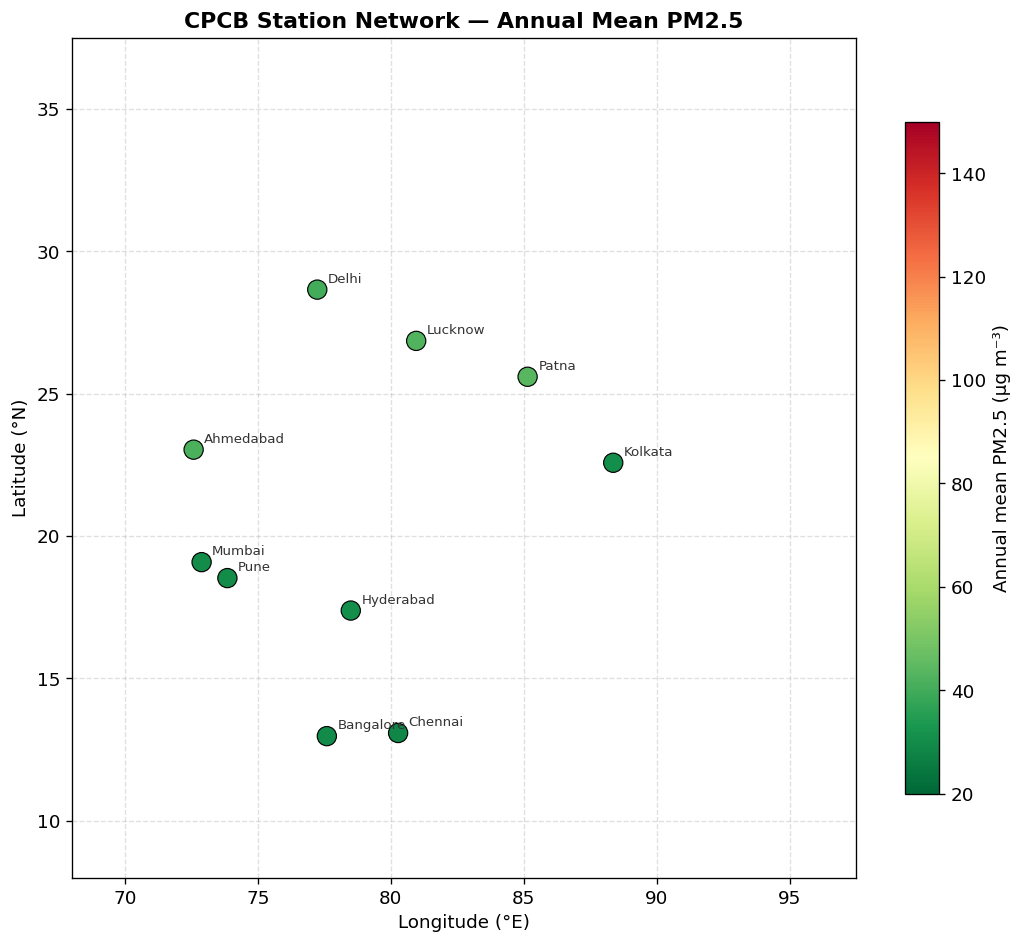

Stations: 10 | Median coverage: 366 days


In [3]:
station_mean = (
    df.groupby(['station_name', 'lat', 'lon'])
      .agg(pm25_mean=('pm25', 'mean'), n_days=('pm25', 'count'))
      .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 8))
sc = ax.scatter(
    station_mean['lon'], station_mean['lat'],
    c=station_mean['pm25_mean'], cmap='RdYlGn_r',
    s=station_mean['n_days'] / 5 + 60,  # size proportional to coverage
    edgecolors='black', linewidths=0.7,
    vmin=20, vmax=150, zorder=3,
)
for _, row in station_mean.iterrows():
    ax.annotate(row['station_name'], (row['lon'] + 0.4, row['lat'] + 0.25),
                fontsize=8, color='#333333')

plt.colorbar(sc, ax=ax, label='Annual mean PM2.5 (µg m⁻³)', shrink=0.8)
ax.set_xlim(68, 97.5); ax.set_ylim(8, 37.5)
ax.set_xlabel('Longitude (°E)'); ax.set_ylabel('Latitude (°N)')
ax.set_title('CPCB Station Network — Annual Mean PM2.5', fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f'Stations: {len(station_mean)} | Median coverage: {station_mean.n_days.median():.0f} days')

## 3. PM2.5 Time Series for Major Cities

The time series reveals clear seasonal cycles:
- **Winter (Dec–Feb):** high PM2.5 due to low boundary layer height, fog, and crop stubble burning
- **Monsoon (Jun–Sep):** PM2.5 drops sharply as rain scavenges aerosols
- **Post-monsoon (Oct–Nov):** sharp peaks in Punjab/Haryana from paddy-field burning

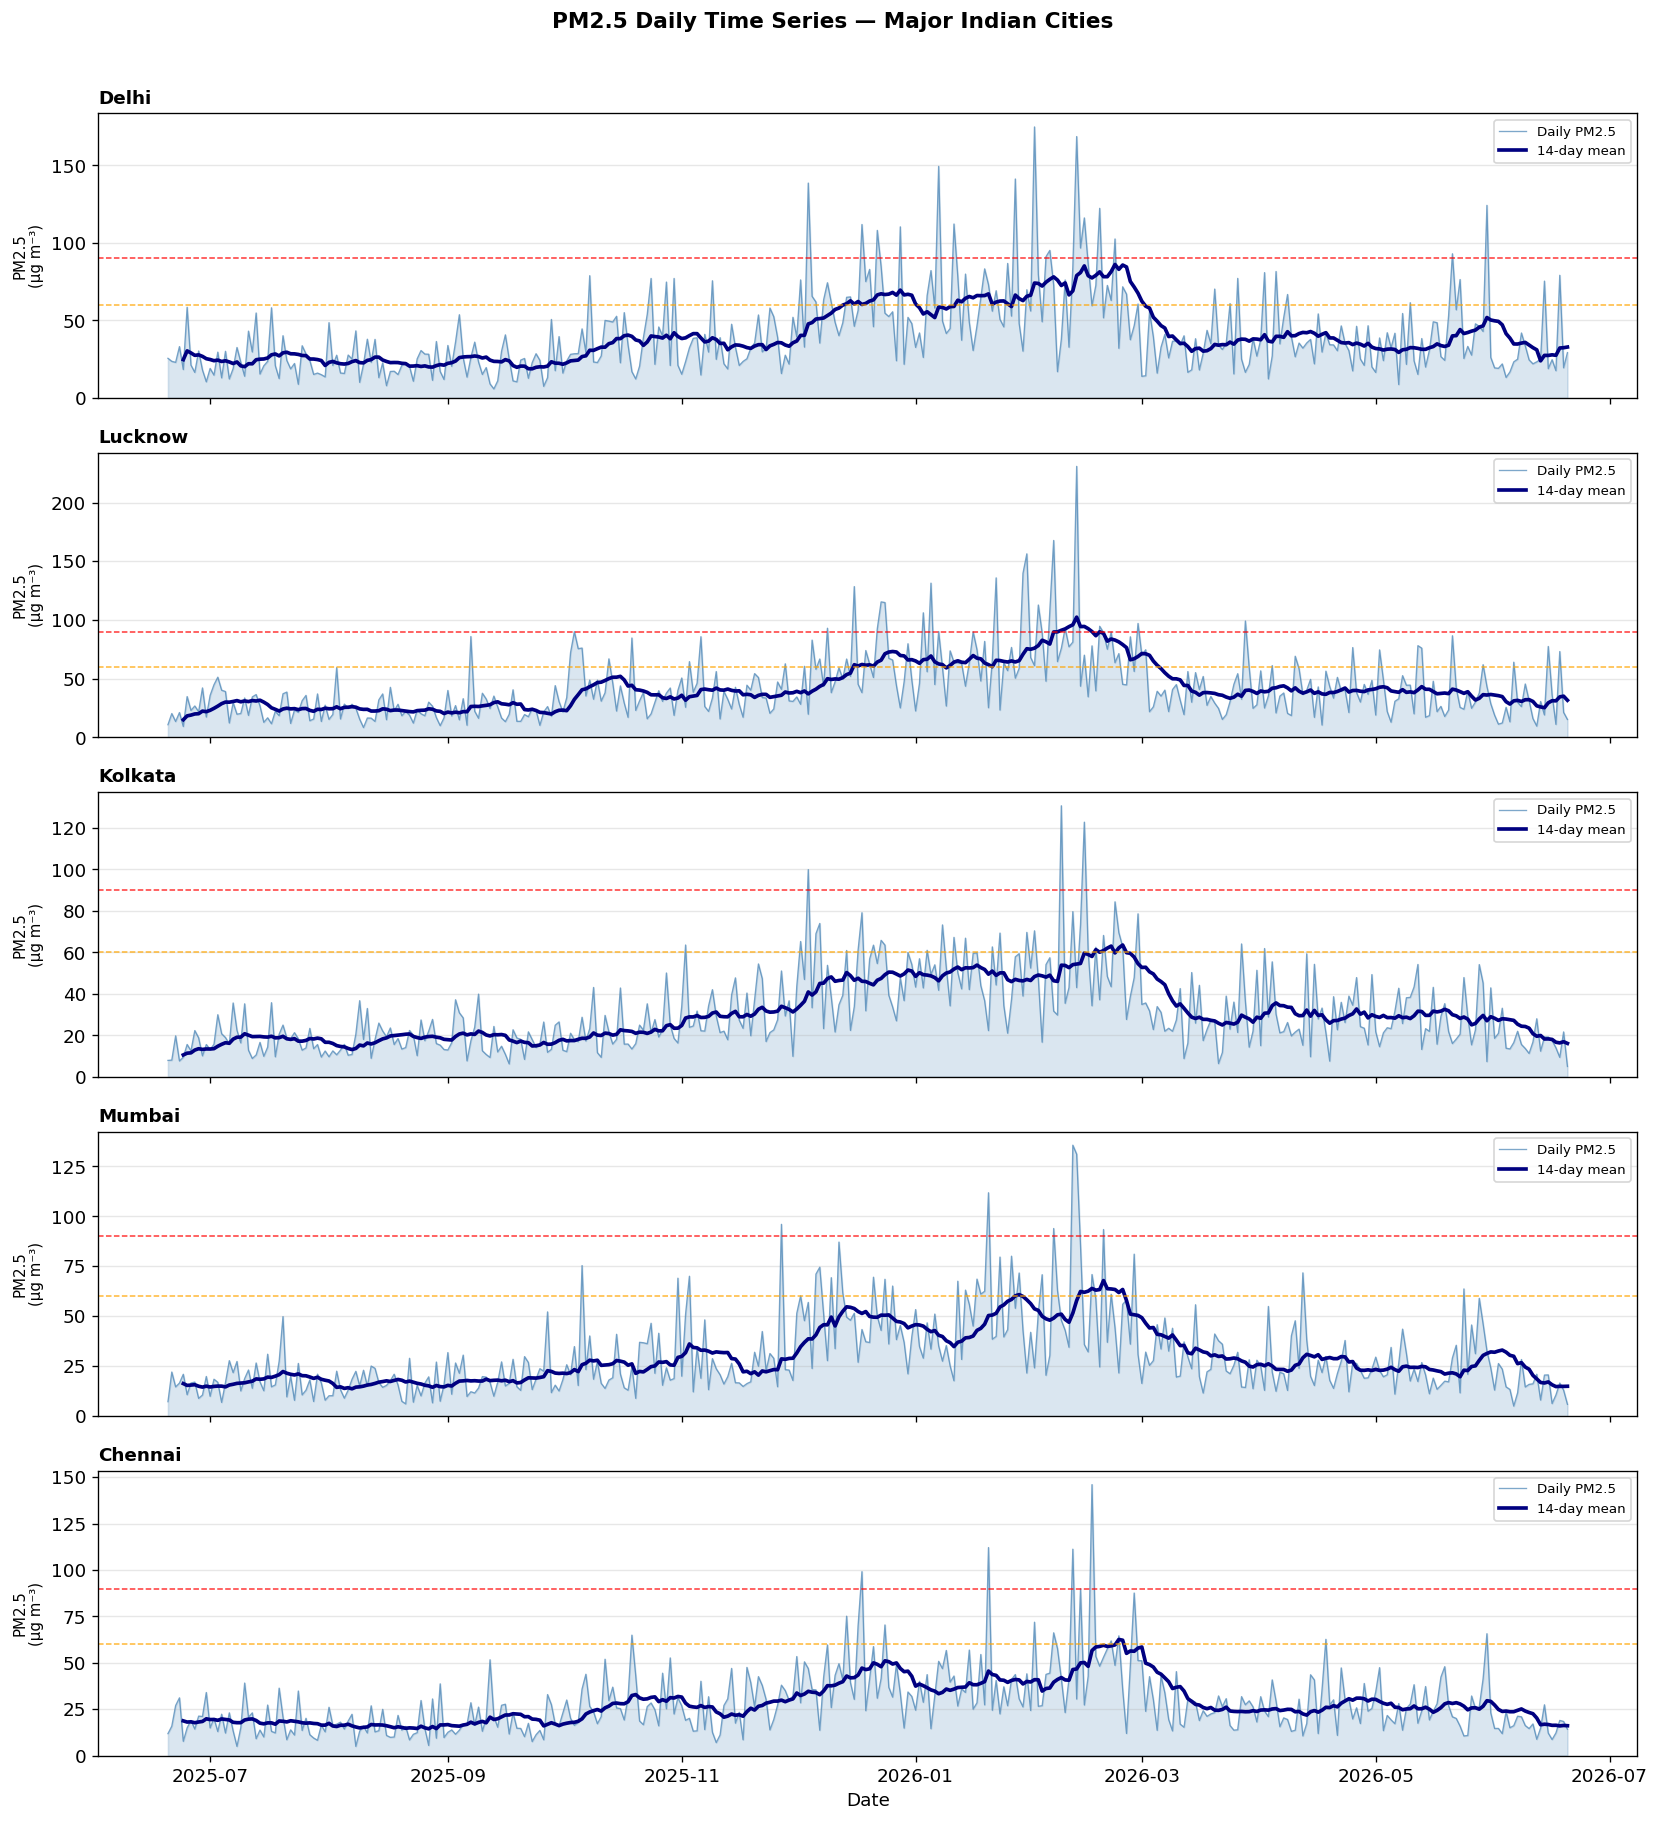

In [4]:
cities_plot = ['Delhi', 'Lucknow', 'Kolkata', 'Mumbai', 'Chennai']
cities_plot = [c for c in cities_plot if c in df['station_name'].unique()]

fig, axes = plt.subplots(len(cities_plot), 1, figsize=(14, 3 * len(cities_plot)),
                         sharex=True)
if len(cities_plot) == 1:
    axes = [axes]

for ax, city in zip(axes, cities_plot):
    cd = df[df['station_name'] == city].sort_values('date')
    ax.fill_between(cd['date'], cd['pm25'], alpha=0.2, color='steelblue')
    ax.plot(cd['date'], cd['pm25'], linewidth=0.8, color='steelblue', alpha=0.7,
            label='Daily PM2.5')
    ax.plot(cd['date'], cd['pm25'].rolling(14, min_periods=5).mean(),
            linewidth=2.2, color='navy', label='14-day mean')
    ax.axhline(60,  color='orange', linestyle='--', linewidth=0.9, alpha=0.8)
    ax.axhline(90,  color='red',    linestyle='--', linewidth=0.9, alpha=0.8)
    ax.set_ylabel('PM2.5\n(µg m⁻³)', fontsize=9)
    ax.set_title(city, fontweight='bold', loc='left', fontsize=11)
    ax.set_ylim(0, None)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, axis='y', alpha=0.3)

axes[-1].set_xlabel('Date')
fig.suptitle('PM2.5 Daily Time Series — Major Indian Cities', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. Missing-Value Analysis

Continuous satellite-derived AQI needs robust imputation of station gaps.
Here we visualise the missingness pattern across pollutants and stations.

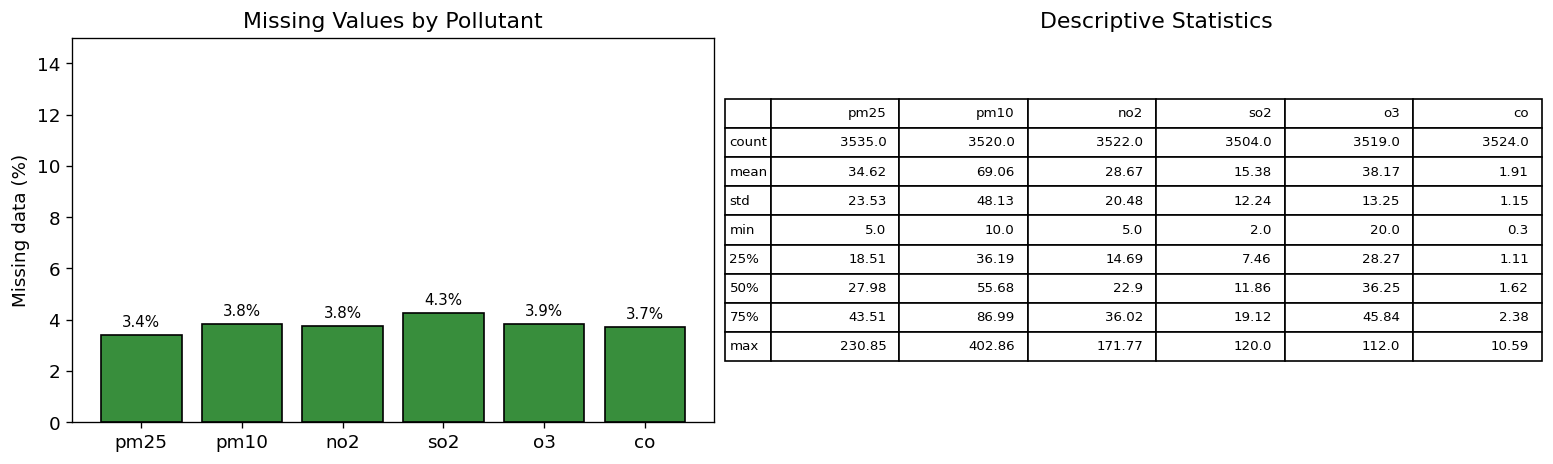


Missing data summary:
pm25    3.415301
pm10    3.825137
no2     3.770492
so2     4.262295
o3      3.852459
co      3.715847


In [5]:
pollutants = ['pm25', 'pm10', 'no2', 'so2', 'o3', 'co']
pollutants = [p for p in pollutants if p in df.columns]

# Introduce a few NaNs in synthetic data to demonstrate
if df[pollutants].isnull().sum().sum() == 0:
    rng2 = np.random.default_rng(99)
    for col in pollutants:
        mask = rng2.random(len(df)) < 0.04  # ~4% random missing
        df.loc[mask, col] = np.nan

missing_pct = df[pollutants].isnull().mean() * 100
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart of overall missing %
colors = ['#d32f2f' if v > 10 else '#f57c00' if v > 5 else '#388e3c'
          for v in missing_pct]
bars = ax1.bar(missing_pct.index, missing_pct.values, color=colors, edgecolor='black')
ax1.set_ylabel('Missing data (%)')
ax1.set_title('Missing Values by Pollutant')
ax1.set_ylim(0, max(missing_pct.max() + 3, 15))
for bar, val in zip(bars, missing_pct.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

# Descriptive statistics
ax2.axis('off')
stats = df[pollutants].describe().round(2)
table_data = [stats.columns.tolist()] + stats.values.tolist()
row_labels = [''] + list(stats.index)
tbl = ax2.table(cellText=table_data, rowLabels=row_labels,
                loc='center', cellLoc='right')
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1.2, 1.4)
ax2.set_title('Descriptive Statistics')

plt.tight_layout()
plt.show()

print('\nMissing data summary:')
print(missing_pct.to_string())

## 5. Indian AQI Computation — CPCB Formula

The CPCB AQI uses a **piecewise linear interpolation** within breakpoint ranges
for each pollutant, then takes the **maximum sub-index** as the overall AQI.
This is the function used in production by `src/utils/aqi_calculator.py`.

Sub-index breakdown:
Pollutant      Conc   Sub-index
----------------------------------
pm25          125.0       304.8
pm10          210.0       173.6
no2            85.0       106.0
so2            45.0        57.1
o3             55.0        55.9
co              2.5       107.2

Overall AQI : 305  (Very Poor)
Dominant    : pm25


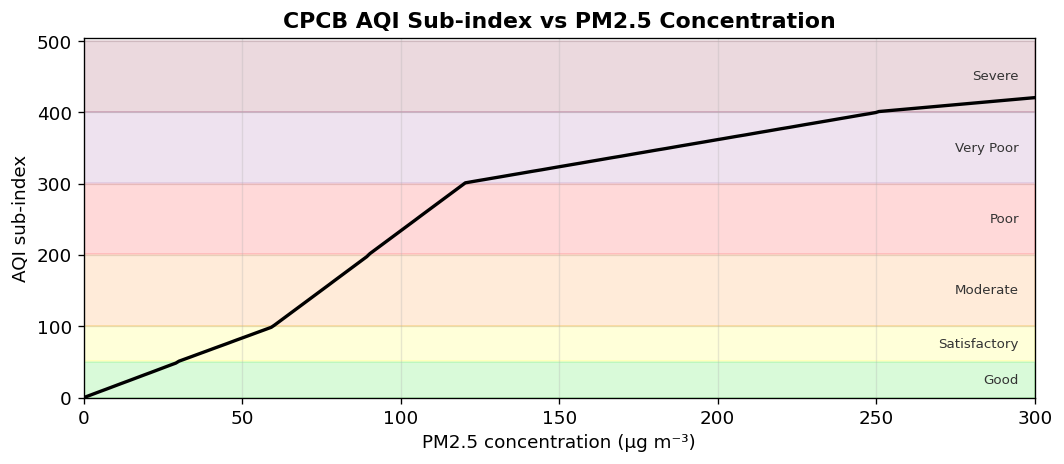

In [6]:
from src.utils.aqi_calculator import (
    compute_indian_aqi, compute_sub_index,
    AQI_CATEGORIES, BREAKPOINTS,
)

# --- Example: compute AQI for a Delhi winter day ---
sample = {'pm25': 125.0, 'pm10': 210.0, 'no2': 85.0,
          'so2': 45.0,  'o3': 55.0,   'co': 2.5}

print('Sub-index breakdown:')
print(f'{"Pollutant":10s} {"Conc":>8s}  {"Sub-index":>10s}')
print('-' * 34)
for poll, conc in sample.items():
    si = compute_sub_index(poll, conc)
    print(f'{poll:10s} {conc:8.1f}  {si if si else "N/A":>10}')

result = compute_indian_aqi(sample)
print(f'\nOverall AQI : {result["aqi"]}  ({result["category"]})')
print(f'Dominant    : {result["dominant_pollutant"]}')

# --- Plot AQI breakpoint curves for PM2.5 ---
pm25_vals = np.linspace(0, 300, 300)
aqi_vals  = [compute_sub_index('pm25', v) or 0 for v in pm25_vals]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(pm25_vals, aqi_vals, 'k-', linewidth=2)
colors_cat = [c[3] for c in AQI_CATEGORIES]
labels_cat = [c[2] for c in AQI_CATEGORIES]
for (lo, hi, cat, col) in AQI_CATEGORIES:
    ax.axhspan(lo, hi, alpha=0.15, color=col)
    ax.text(295, (lo + hi) / 2, cat, va='center', ha='right', fontsize=8, color='#333')
ax.set_xlabel('PM2.5 concentration (µg m⁻³)')
ax.set_ylabel('AQI sub-index')
ax.set_title('CPCB AQI Sub-index vs PM2.5 Concentration', fontweight='bold')
ax.set_xlim(0, 300); ax.set_ylim(0, 505)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Seasonal PM2.5 Distribution

Using IMD seasons:
- **Winter** (Dec–Feb): coldest, lowest BLH, highest PM2.5
- **Pre-monsoon** (Mar–May): dust events, moderate PM2.5
- **Monsoon** (Jun–Sep): washout, lowest PM2.5
- **Post-monsoon** (Oct–Nov): crop residue burning peaks in IGP

C:\Users\manas\AppData\Local\Temp\ipykernel_18124\3076470077.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(data_box, labels=order, patch_artist=True,


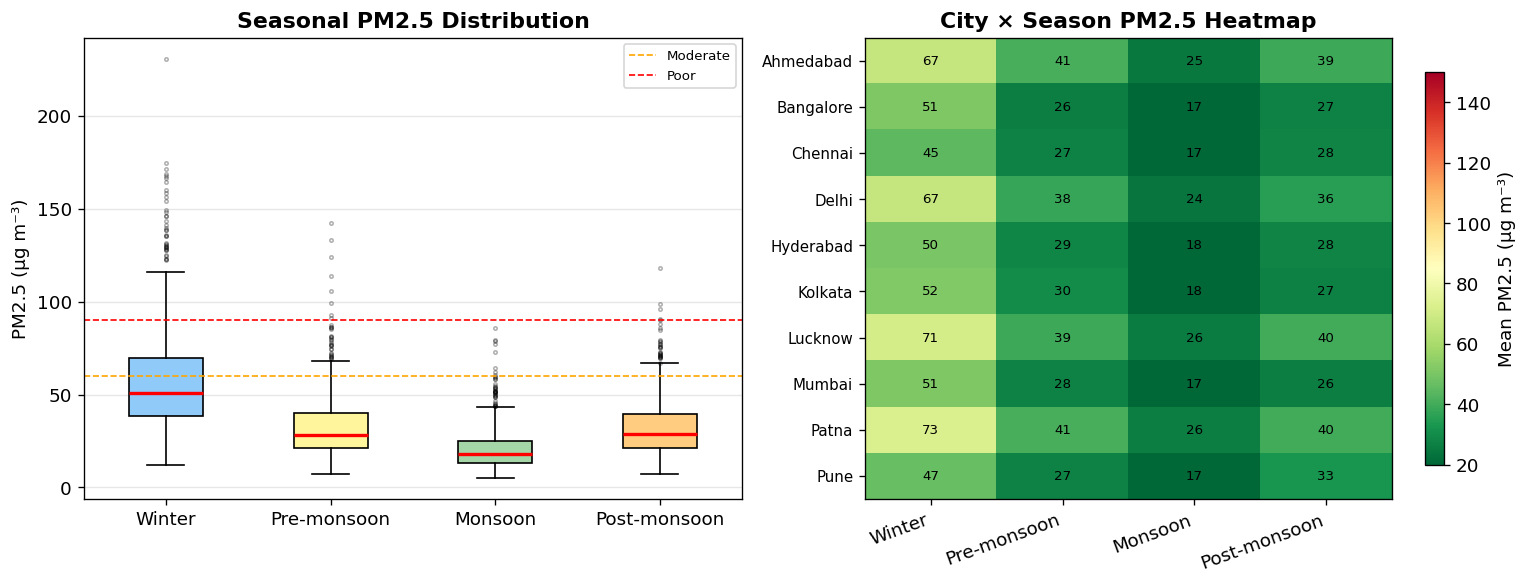


Seasonal summary statistics:
              mean  median   std
season                          
Winter        57.4    50.7  28.6
Pre-monsoon   32.5    28.5  16.9
Monsoon       20.6    18.1  10.7
Post-monsoon  32.3    28.8  16.4


In [7]:
season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Pre-monsoon', 4: 'Pre-monsoon', 5: 'Pre-monsoon',
    6: 'Monsoon', 7: 'Monsoon', 8: 'Monsoon', 9: 'Monsoon',
    10: 'Post-monsoon', 11: 'Post-monsoon',
}
df['season'] = df['date'].dt.month.map(season_map)

order = ['Winter', 'Pre-monsoon', 'Monsoon', 'Post-monsoon']
pal   = ['#90caf9', '#fff59d', '#a5d6a7', '#ffcc80']
data_box = [df.loc[df['season'] == s, 'pm25'].dropna().values for s in order]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

bp = ax1.boxplot(data_box, labels=order, patch_artist=True,
                 medianprops=dict(color='red', linewidth=2),
                 flierprops=dict(marker='o', markersize=2, alpha=0.3))
for patch, color in zip(bp['boxes'], pal):
    patch.set_facecolor(color)
ax1.set_ylabel('PM2.5 (µg m⁻³)')
ax1.set_title('Seasonal PM2.5 Distribution', fontweight='bold')
ax1.axhline(60, color='orange', linestyle='--', linewidth=1, label='Moderate')
ax1.axhline(90, color='red',    linestyle='--', linewidth=1, label='Poor')
ax1.legend(fontsize=8)
ax1.grid(True, axis='y', alpha=0.3)

# City-season heatmap
pivot = df.groupby(['city', 'season'])['pm25'].mean().unstack()
pivot = pivot.reindex(columns=order)
im = ax2.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto', vmin=20, vmax=150)
plt.colorbar(im, ax=ax2, label='Mean PM2.5 (µg m⁻³)', shrink=0.85)
ax2.set_xticks(range(len(order))); ax2.set_xticklabels(order, rotation=20, ha='right')
ax2.set_yticks(range(len(pivot))); ax2.set_yticklabels(pivot.index, fontsize=9)
ax2.set_title('City × Season PM2.5 Heatmap', fontweight='bold')
for i in range(len(pivot)):
    for j in range(len(order)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax2.text(j, i, f'{val:.0f}', ha='center', va='center',
                     fontsize=8, color='black')

plt.tight_layout()
plt.show()

print('\nSeasonal summary statistics:')
print(df.groupby('season')['pm25'].agg(['mean','median','std']).reindex(order).round(1))